# Notebook 16 – Deep Learning Model Analysis



## 1. What is Model Evaluation?

**Model evaluation** means checking how well a trained machine learning or deep learning model performs on data that it did not use for learning.

Training accuracy alone is not enough.

For example, suppose:

- Training accuracy = 99%
- Validation accuracy = 72%

The model looks excellent on training data, but its performance drops on unseen data.

This tells us that the model may have **overfitted**.

### Real-world example

Imagine a student memorizes the exact questions from practice tests and gets 100% on those questions. If the student performs poorly on new questions, memorization happened instead of real understanding.

A neural network can behave in a similar way.

### AI/ML usage

Model evaluation is used in:

- Image classification
- Fraud detection
- Medical prediction
- Customer churn prediction
- Recommendation systems
- OCR
- Speech recognition

The purpose is to understand whether the model can generalize to new data.

## 2. Understanding the Dataset

The Online Retail dataset contains transaction information such as:

- Invoice number
- Product code
- Product description
- Quantity
- Invoice date
- Unit price
- Customer ID
- Country

For this notebook, I use transaction-level numerical and date-based features to predict whether a transaction is a cancelled transaction.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_recall_fscore_support

df = pd.read_csv("data.csv", encoding="latin1")

print("Shape:", df.shape)
print(df.head())

Shape: (541909, 8)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  


### What did I learn from the first inspection?

The dataset has more than 500,000 transaction records.

The important point for model analysis is that I should understand the data before interpreting the model results.

The dataset also contains missing values in `Description` and `CustomerID`. For this simple model, I do not need the product description text, and I handle the missing customer ID using a separate missing-value indicator.

## 3. Creating the Target Variable

The original dataset does not contain a column called `Target`.

I create:

`Cancelled = 1` when the invoice number starts with `C`.

Otherwise:

`Cancelled = 0`

This creates a binary classification problem.

### Real-world meaning

An e-commerce company could use transaction information to study patterns associated with cancelled transactions.

### AI/ML usage

Binary classification is commonly used for:

- Fraud vs normal
- Spam vs not spam
- Churn vs retained
- Defective vs non-defective
- Cancelled vs normal

In [2]:
df["Cancelled"] = df["InvoiceNo"].astype(str).str.startswith("C").astype(int)

print(df["Cancelled"].value_counts())
print(df["Cancelled"].value_counts(normalize=True))

Cancelled
0    532621
1      9288
Name: count, dtype: int64
Cancelled
0    0.982861
1    0.017139
Name: proportion, dtype: float64


## 4. Feature Engineering

I create simple features from the existing columns.

Features used:

- `Quantity`
- `UnitPrice`
- `CustomerID`
- `CustomerMissing`
- `Hour`
- `DayOfWeek`
- `Month`

The date is converted into useful numerical information.

### Why feature engineering matters

A raw date such as `12/1/2010 8:26` is not directly useful to a simple neural network.

Breaking it into hour, weekday and month gives the model numerical patterns it can learn.

### Real-world example

For food delivery, the exact timestamp can be converted into:

- Morning/evening
- Weekday/weekend
- Month
- Peak hour

These features may help predict order cancellation or demand.

### AI/ML usage

Feature engineering is used before many ML and DL models because better representations can make learning easier.

In [3]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["CustomerMissing"] = df["CustomerID"].isna().astype(int)
df["Hour"] = df["InvoiceDate"].dt.hour
df["DayOfWeek"] = df["InvoiceDate"].dt.dayofweek
df["Month"] = df["InvoiceDate"].dt.month
df["CustomerID"] = df["CustomerID"].fillna(df["CustomerID"].median())

features = ["Quantity", "UnitPrice", "CustomerID", "CustomerMissing", "Hour", "DayOfWeek", "Month"]

X = df[features].copy()
y = df["Cancelled"].copy()

print(X.head())
print(y.head())

   Quantity  UnitPrice  CustomerID  CustomerMissing  Hour  DayOfWeek  Month
0         6       2.55     17850.0                0     8          2     12
1         6       3.39     17850.0                0     8          2     12
2         8       2.75     17850.0                0     8          2     12
3         6       3.39     17850.0                0     8          2     12
4         6       3.39     17850.0                0     8          2     12
0    0
1    0
2    0
3    0
4    0
Name: Cancelled, dtype: int64


## 5. Train and Validation Data

I split the dataset into:

- **Training data: 80%**
- **Validation data: 20%**

The training set is used to learn the model parameters.

The validation set is used to check how the model behaves on unseen examples.

### Why validation data is important

If I only check the training data, I cannot properly detect overfitting.

### AI/ML usage

Validation data is used for:

- Choosing model architecture
- Monitoring training
- Comparing models
- Detecting overfitting
- Selecting useful hyperparameters

In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Training class distribution:")
print(y_train.value_counts(normalize=True))
print("Validation class distribution:")
print(y_val.value_counts(normalize=True))

Training samples: 433527
Validation samples: 108382
Training class distribution:
Cancelled
0    0.982862
1    0.017138
Name: proportion, dtype: float64
Validation class distribution:
Cancelled
0    0.982857
1    0.017143
Name: proportion, dtype: float64


## 6. Feature Scaling

Neural networks usually learn more easily when numerical features have comparable scales.

For example:

- Quantity may contain very large values.
- CustomerID may be around thousands.
- Hour is between 0 and 23.

Standardization transforms the features so their scales are more comparable.

### Formula

**z = (x - mean) / standard deviation**

### AI/ML usage

Scaling is commonly useful for:

- Neural networks
- Logistic regression
- KNN
- SVM
- Gradient-based optimization

Tree-based models usually do not require the same type of scaling.

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("Training feature shape:", X_train_scaled.shape)
print("Validation feature shape:", X_val_scaled.shape)

Training feature shape: (433527, 7)
Validation feature shape: (108382, 7)


## 7. Creating PyTorch Tensors

PyTorch neural networks work with tensors.

A tensor is a data structure that can store numerical values and is designed for efficient mathematical operations.

Here the feature matrix becomes a tensor and the target becomes a tensor.

### AI/ML usage

Tensors are the basic data structure used by PyTorch for:

- Inputs
- Weights
- Biases
- Activations
- Loss values
- Gradients

In [6]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

print(X_train_tensor.shape)
print(y_train_tensor.shape)

torch.Size([433527, 7])
torch.Size([433527, 1])


## 8. Building a Simple Neural Network

I use a small feed-forward neural network.

Architecture:

**Input features → Hidden layer → ReLU → Hidden layer → ReLU → Output**

The output contains one value because this is binary classification.

### Why use ReLU?

ReLU introduces non-linearity.

Without non-linear activation functions, stacking many linear transformations would still behave like a linear model.

### Real-world example

A simple neural network can be used to learn patterns such as:

**transaction features → probability of cancellation**

### AI/ML usage

Feed-forward neural networks are used for:

- Tabular classification
- Risk prediction
- Customer prediction
- Business forecasting
- Binary classification problems

In [7]:
class RetailClassifier(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)

model = RetailClassifier(X_train_tensor.shape[1])

print(model)

RetailClassifier(
  (network): Sequential(
    (0): Linear(in_features=7, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)


## 9. Loss Function and Optimizer

I use **BCEWithLogitsLoss** for binary classification.

It combines:

- Sigmoid operation
- Binary cross entropy

in a numerically stable way.

The optimizer is Adam.

### Why loss is needed

Accuracy only tells us whether the final class is correct.

Loss gives the model a continuous signal showing how far its predictions are from the correct answers.

### AI/ML usage

Loss functions guide neural networks during training by telling the optimizer how the model should change its weights.

In [8]:
positive_count = y_train.sum()
negative_count = len(y_train) - positive_count
pos_weight = torch.tensor([negative_count / positive_count], dtype=torch.float32)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Positive class weight:", pos_weight.item())

Positive class weight: 57.348182678222656


## 10. Training the Model

During every epoch:

1. The model receives training data.
2. It produces predictions.
3. The loss is calculated.
4. Gradients are calculated.
5. The optimizer updates the weights.
6. Training loss and validation loss are recorded.

Recording both training and validation metrics is important because their relationship tells us about model behavior.

In [9]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)

epochs = 10
history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": []
}

for epoch in range(epochs):
    model.train()
    train_loss_total = 0
    train_correct = 0
    train_total = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        train_loss_total += loss.item() * X_batch.size(0)
        predictions = (torch.sigmoid(logits) >= 0.5).float()
        train_correct += (predictions == y_batch).sum().item()
        train_total += y_batch.size(0)

    model.eval()
    val_loss_total = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            val_loss_total += loss.item() * X_batch.size(0)
            predictions = (torch.sigmoid(logits) >= 0.5).float()
            val_correct += (predictions == y_batch).sum().item()
            val_total += y_batch.size(0)

    train_loss = train_loss_total / train_total
    val_loss = val_loss_total / val_total
    train_accuracy = train_correct / train_total
    val_accuracy = val_correct / val_total

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_accuracy"].append(val_accuracy)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.4f} | "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

Epoch 1/10 | Train Loss: 1.0601 | Val Loss: 0.7263 | Train Accuracy: 0.6767 | Val Accuracy: 0.8935
Epoch 2/10 | Train Loss: 0.4972 | Val Loss: 0.3226 | Train Accuracy: 0.8984 | Val Accuracy: 0.9485
Epoch 3/10 | Train Loss: 0.2490 | Val Loss: 0.1768 | Train Accuracy: 0.9713 | Val Accuracy: 0.9924
Epoch 4/10 | Train Loss: 0.1358 | Val Loss: 0.0865 | Train Accuracy: 0.9920 | Val Accuracy: 0.9961
Epoch 5/10 | Train Loss: 0.0692 | Val Loss: 0.0444 | Train Accuracy: 0.9959 | Val Accuracy: 0.9971
Epoch 6/10 | Train Loss: 0.0329 | Val Loss: 0.0263 | Train Accuracy: 0.9965 | Val Accuracy: 0.9962
Epoch 7/10 | Train Loss: 0.0220 | Val Loss: 0.0151 | Train Accuracy: 0.9961 | Val Accuracy: 0.9969
Epoch 8/10 | Train Loss: 0.0130 | Val Loss: 0.0090 | Train Accuracy: 0.9971 | Val Accuracy: 0.9973
Epoch 9/10 | Train Loss: 0.0126 | Val Loss: 0.0079 | Train Accuracy: 0.9965 | Val Accuracy: 0.9973
Epoch 10/10 | Train Loss: 0.0082 | Val Loss: 0.0070 | Train Accuracy: 0.9972 | Val Accuracy: 0.9975


## 11. Training Accuracy vs Validation Accuracy

### Definition

**Training accuracy** is the percentage of correct predictions on the training data.

**Validation accuracy** is the percentage of correct predictions on unseen validation data.

### What should I look for?

If both are high and close together:

The model may be generalizing well.

If training accuracy is much higher than validation accuracy:

The model may be overfitting.

If both are low:

The model may be underfitting, the features may be weak, or the problem may be difficult.

### Real-world example

A fraud model may perform very well on old transactions but poorly on new transactions. The validation result helps reveal this problem.

### AI/ML usage

Comparing training and validation accuracy is one of the simplest ways to monitor generalization.

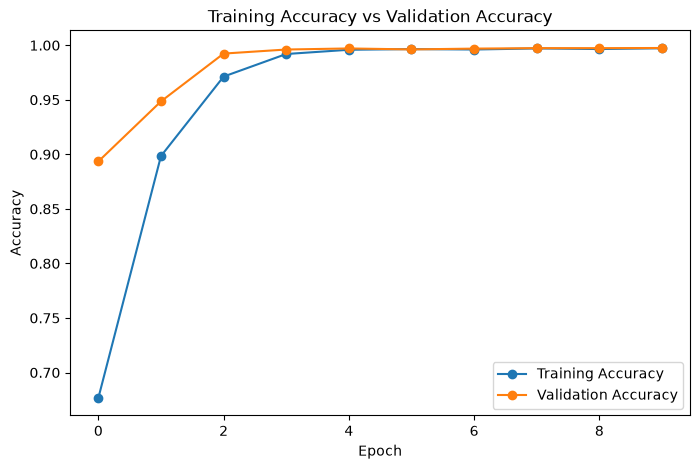

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_accuracy"], marker="o", label="Training Accuracy")
plt.plot(history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Validation Accuracy")
plt.legend()
plt.show()

## 12. Training Loss vs Validation Loss

### Definition

Loss measures how far the model predictions are from the target values.

A decreasing training loss means the model is learning the training examples.

The validation loss tells us whether that learning is also useful for unseen examples.

### Typical overfitting pattern

Training loss keeps decreasing while validation loss starts increasing.

This means the model is becoming better at the training data but worse at unseen data.

### AI/ML usage

Loss curves are especially useful during deep learning because they show the learning process across epochs, not just one final score.

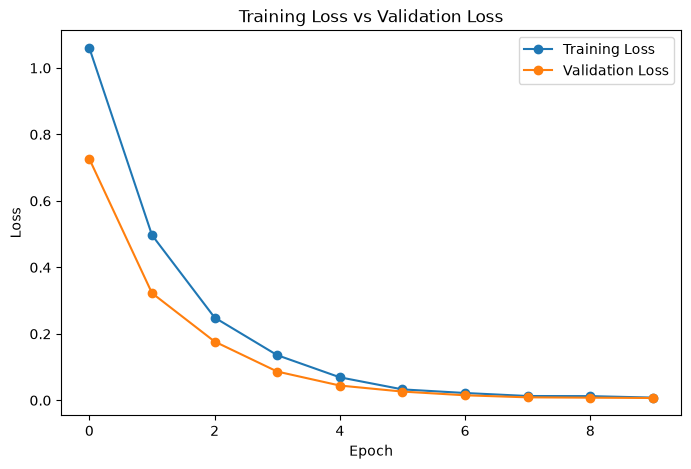

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], marker="o", label="Training Loss")
plt.plot(history["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Validation Loss")
plt.legend()
plt.show()

## 13. Checking for Overfitting

### Definition

**Overfitting** happens when a model learns the training data too specifically and does not generalize well to unseen data.

### Signs

- Training accuracy is much higher than validation accuracy.
- Training loss continues decreasing.
- Validation loss starts increasing.
- Validation performance stops improving.

### Real-world example

A customer churn model may memorize patterns from old customers instead of learning general churn behavior.

### How to reduce overfitting

Possible solutions:

- More training data
- Data augmentation where appropriate
- Dropout
- Regularization
- Smaller model
- Early stopping
- Better feature selection

### AI/ML usage

Overfitting is one of the main problems when training flexible deep learning models.

In [12]:
accuracy_gap = history["train_accuracy"][-1] - history["val_accuracy"][-1]
loss_gap = history["val_loss"][-1] - history["train_loss"][-1]

print("Final training accuracy:", history["train_accuracy"][-1])
print("Final validation accuracy:", history["val_accuracy"][-1])
print("Accuracy gap:", accuracy_gap)
print("Final training loss:", history["train_loss"][-1])
print("Final validation loss:", history["val_loss"][-1])
print("Loss gap:", loss_gap)

if accuracy_gap > 0.05 and history["val_loss"][-1] > history["train_loss"][-1]:
    print("Possible overfitting pattern detected.")
else:
    print("A strong overfitting pattern is not obvious from the final metrics.")

Final training accuracy: 0.9972158596811732
Final validation accuracy: 0.9974811315532099
Accuracy gap: -0.00026527187203673197
Final training loss: 0.008181651219912718
Final validation loss: 0.0069695995683044165
Loss gap: -0.0012120516516083016
A strong overfitting pattern is not obvious from the final metrics.


## 14. Checking for Underfitting

### Definition

**Underfitting** happens when the model is too simple or has not learned enough useful patterns.

### Signs

- Training accuracy is low.
- Validation accuracy is also low.
- Training loss remains high.
- Validation performance does not improve enough.

### Possible reasons

- Model is too small.
- Training time is too short.
- Learning rate is unsuitable.
- Features do not contain enough useful information.
- The problem is difficult.

### AI/ML usage

Underfitting analysis helps decide whether the model needs more capacity, better features or more training.

In [13]:
best_val_accuracy = max(history["val_accuracy"])
best_epoch = history["val_accuracy"].index(best_val_accuracy) + 1

print("Best validation accuracy:", best_val_accuracy)
print("Best validation epoch:", best_epoch)

if history["train_accuracy"][-1] < 0.70 and history["val_accuracy"][-1] < 0.70:
    print("The model may be underfitting.")
else:
    print("The final metrics do not show a strong underfitting pattern.")

Best validation accuracy: 0.9974811315532099
Best validation epoch: 10
The final metrics do not show a strong underfitting pattern.


## 15. Final Validation Predictions

Now I generate predictions for the complete validation set.

I convert the neural network output into probabilities using sigmoid.

Then I use 0.5 as the classification threshold.

- Probability >= 0.5 → Cancelled
- Probability < 0.5 → Normal

This gives us the predicted classes needed for confusion matrix and error analysis.

In [14]:
model.eval()

with torch.no_grad():
    val_logits = model(X_val_tensor)
    val_probabilities = torch.sigmoid(val_logits).numpy().ravel()

y_true = y_val.to_numpy()
y_pred = (val_probabilities >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_true, y_pred))

Accuracy: 0.9974811315532099


## 16. Confusion Matrix

### Definition

A confusion matrix shows how the actual classes compare with the predicted classes.

For binary classification:

| Actual / Predicted | Normal | Cancelled |
|---|---:|---:|
| Normal | True Negative | False Positive |
| Cancelled | False Negative | True Positive |

### Why it is useful

Accuracy can hide the type of mistake.

For example, a model may have good accuracy but miss many cancelled transactions.

### AI/ML usage

Confusion matrices are widely used in:

- Fraud detection
- Medical diagnosis
- Spam detection
- Image classification
- Defect detection

Confusion Matrix:
[[106252    272]
 [     1   1857]]


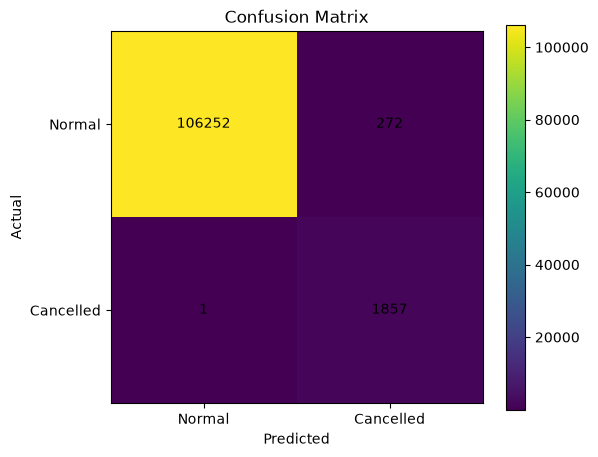

In [15]:
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.xticks([0, 1], ["Normal", "Cancelled"])
plt.yticks([0, 1], ["Normal", "Cancelled"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

## 17. Class-wise Performance

Accuracy gives one overall number.

Class-wise metrics tell us how well the model performs for each class.

Important metrics:

### Precision

Of the transactions predicted as a class, how many were actually that class?

**Precision = TP / (TP + FP)**

### Recall

Of the transactions that actually belong to a class, how many did the model find?

**Recall = TP / (TP + FN)**

### F1-score

F1-score combines precision and recall.

**F1 = 2 × Precision × Recall / (Precision + Recall)**

### Why this matters

For cancelled transactions, recall can be important if the business wants to identify as many cancellations as possible.

### AI/ML usage

Class-wise evaluation is especially important when classes are imbalanced or when different types of mistakes have different business costs.

In [16]:
report = classification_report(
    y_true,
    y_pred,
    target_names=["Normal", "Cancelled"],
    digits=4
)

print(report)

              precision    recall  f1-score   support

      Normal     1.0000    0.9974    0.9987    106524
   Cancelled     0.8722    0.9995    0.9315      1858

    accuracy                         0.9975    108382
   macro avg     0.9361    0.9985    0.9651    108382
weighted avg     0.9978    0.9975    0.9976    108382



## 18. Finding the Poorly Performing Class

A class can be considered difficult when its precision, recall or F1-score is much lower than the other class.

I do not want to judge the model only from overall accuracy.

Instead, I compare the class-wise metrics.

### Possible reasons for a poorly performing class

- Not enough examples
- Similarity between classes
- Weak features
- Noisy labels
- Class imbalance
- Model capacity limitations

### AI/ML usage

This analysis is useful when improving models because it tells us where the model needs attention.

In [17]:
precision, recall, f1, support = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=[0, 1],
    zero_division=0
)

class_metrics = pd.DataFrame({
    "Class": ["Normal", "Cancelled"],
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "Support": support
})

print(class_metrics)

       Class  Precision    Recall        F1  Support
0     Normal   0.999991  0.997447  0.998717   106524
1  Cancelled   0.872240  0.999462  0.931527     1858


## 19. Misclassified Samples

### Definition

A misclassified sample is an example where the predicted class is different from the actual class.

These examples are extremely useful because they show **where the model is making mistakes**.

Instead of looking only at one number, I can inspect the actual transaction features.

### Real-world example

In a fraud detection system, examining false negatives may reveal a type of fraud pattern that the model has not learned.

### AI/ML usage

Misclassified samples help with:

- Feature engineering
- Data cleaning
- Model improvement
- Error analysis
- Detecting unusual cases

In [18]:
val_analysis = X_val.copy()
val_analysis["Actual"] = y_true
val_analysis["Predicted"] = y_pred
val_analysis["Probability_Cancelled"] = val_probabilities
val_analysis["Correct"] = val_analysis["Actual"] == val_analysis["Predicted"]

misclassified = val_analysis[val_analysis["Correct"] == False].copy()

print("Number of misclassified samples:", len(misclassified))
print(misclassified.head(20))

Number of misclassified samples: 273
        Quantity  UnitPrice  CustomerID  CustomerMissing  Hour  DayOfWeek  \
277389        -5       0.00     15152.0                1    11          0   
275219        -3       0.00     15152.0                1    11          4   
415121       -71       0.00     15152.0                1    14          0   
46883       -201       0.00     15152.0                1    16          3   
222006       -30       0.00     15152.0                1    10          4   
280659        -2       0.00     15152.0                1    13          2   
201752        -1       0.00     15152.0                1    15          0   
171576        -5       0.00     15152.0                1    15          3   
21349        -80       0.00     15152.0                1    14          3   
148080        -9       0.00     15152.0                1    17          2   
170484       -18       0.00     15152.0                1    14          2   
178020      -160       0.00     15152.0

## 20. False Positives and False Negatives

There are two important error types.

### False Positive

Actual = Normal

Predicted = Cancelled

The model raises a cancellation signal when the transaction is actually normal.

### False Negative

Actual = Cancelled

Predicted = Normal

The model misses a cancelled transaction.

### Why separate them?

The business impact can be different.

For example, if the goal is to catch as many risky transactions as possible, false negatives may be more important.

### AI/ML usage

Separating error types is common in:

- Fraud detection
- Medical screening
- Security systems
- Spam filtering
- Quality inspection

In [19]:
false_positive = val_analysis[
    (val_analysis["Actual"] == 0) &
    (val_analysis["Predicted"] == 1)
]

false_negative = val_analysis[
    (val_analysis["Actual"] == 1) &
    (val_analysis["Predicted"] == 0)
]

print("False positives:", len(false_positive))
print("False negatives:", len(false_negative))

print("False positive examples:")
print(false_positive.head(10))

print("False negative examples:")
print(false_negative.head(10))

False positives: 272
False negatives: 1
False positive examples:
        Quantity  UnitPrice  CustomerID  CustomerMissing  Hour  DayOfWeek  \
277389        -5        0.0     15152.0                1    11          0   
275219        -3        0.0     15152.0                1    11          4   
415121       -71        0.0     15152.0                1    14          0   
46883       -201        0.0     15152.0                1    16          3   
222006       -30        0.0     15152.0                1    10          4   
280659        -2        0.0     15152.0                1    13          2   
201752        -1        0.0     15152.0                1    15          0   
171576        -5        0.0     15152.0                1    15          3   
21349        -80        0.0     15152.0                1    14          3   
148080        -9        0.0     15152.0                1    17          2   

        Month  Actual  Predicted  Probability_Cancelled  Correct  
277389      7       

## 21. Looking for Error Patterns

Error analysis means looking for repeated patterns among wrong predictions.

For example, I can compare:

- Quantity
- Unit price
- Customer information
- Hour
- Weekday
- Month

between correctly classified and misclassified transactions.

### Why this matters

If most errors occur around certain values or time periods, the problem may not simply be the neural network.

The features may not represent the real business process well.

### AI/ML usage

Error pattern analysis can lead to:

- New features
- Better preprocessing
- Different model architecture
- More training data
- Better labels

In [20]:
correct = val_analysis[val_analysis["Correct"]].copy()

pattern_summary = pd.DataFrame({
    "Group": ["Correct", "Misclassified"],
    "Average Quantity": [correct["Quantity"].mean(), misclassified["Quantity"].mean()],
    "Average UnitPrice": [correct["UnitPrice"].mean(), misclassified["UnitPrice"].mean()],
    "Average Hour": [correct["Hour"].mean(), misclassified["Hour"].mean()],
    "Average CustomerID": [correct["CustomerID"].mean(), misclassified["CustomerID"].mean()]
})

print(pattern_summary)

           Group  Average Quantity  Average UnitPrice  Average Hour  \
0        Correct         10.916122           4.289740     13.073509   
1  Misclassified       -143.117216         111.094176     13.476190   

   Average CustomerID  
0        15251.852667  
1        15128.919414  


## 22. Visualizing Misclassified Samples

A useful way to understand errors is to compare the feature distributions of correct and incorrect predictions.

Here I compare quantity because it is one of the strongest transaction-level features.

If the distributions overlap heavily, the model may have difficulty separating the classes from this feature alone.

If the distributions are clearly different, the feature may be helping the model make its decisions.

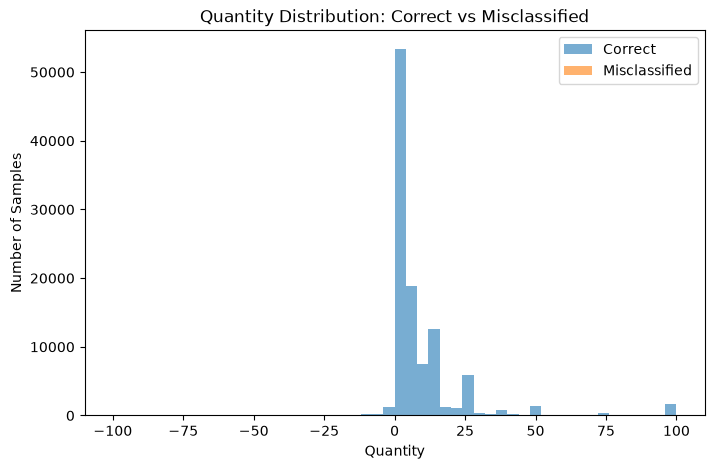

In [21]:
plt.figure(figsize=(8, 5))
plt.hist(correct["Quantity"].clip(-100, 100), bins=50, alpha=0.6, label="Correct")
plt.hist(misclassified["Quantity"].clip(-100, 100), bins=50, alpha=0.6, label="Misclassified")
plt.xlabel("Quantity")
plt.ylabel("Number of Samples")
plt.title("Quantity Distribution: Correct vs Misclassified")
plt.legend()
plt.show()

## 23. Data-related Problems

Some model problems are actually data problems.

Possible data-related problems in this dataset include:

### Missing values

CustomerID contains missing values.

Missing information can reduce the usefulness of customer-related features.

### Class imbalance

Cancelled transactions are much less common than normal transactions.

If we ignored the imbalance, the model could focus mainly on the majority class.

### Extreme values

Quantity and UnitPrice contain unusual values.

Extreme values can influence model training.

### Target construction

The target was created from the invoice number pattern.

This means the target definition itself is important to understand before interpreting model performance.

### AI/ML usage

Data quality often has a bigger effect on model performance than changing the neural-network architecture.

In [22]:
print("Missing values:")
print(df[features].isna().sum())

print()
print("Target distribution:")
print(df["Cancelled"].value_counts())

print()
print("Quantity range:", df["Quantity"].min(), "to", df["Quantity"].max())
print("UnitPrice range:", df["UnitPrice"].min(), "to", df["UnitPrice"].max())

Missing values:
Quantity           0
UnitPrice          0
CustomerID         0
CustomerMissing    0
Hour               0
DayOfWeek          0
Month              0
dtype: int64

Target distribution:
Cancelled
0    532621
1      9288
Name: count, dtype: int64

Quantity range: -80995 to 80995
UnitPrice range: -11062.06 to 38970.0


## 24. Model-related Problems

Even when the data is reasonable, the model can have problems.

Possible model-related causes include:

- Too few hidden units
- Too many hidden units
- Poor learning rate
- Too few epochs
- Too many epochs
- Weak architecture
- Poor regularization
- Incorrect decision threshold

### Example

If training accuracy is very high but validation accuracy is much lower, increasing model size may make the problem worse because the model may memorize the training data.

### AI/ML usage

Model analysis helps decide whether to change:

- Architecture
- Optimizer
- Learning rate
- Batch size
- Epochs
- Regularization

## 25. Class Confusion

### Definition

Class confusion occurs when the model repeatedly confuses one class with another.

In this binary problem, the main confusion is:

**Normal ↔ Cancelled**

The confusion matrix shows exactly how many examples fall into each category.

### Why can confusion happen?

Possible reasons include:

- Similar feature values
- Insufficient information
- Noisy data
- Overlapping classes
- Weak features
- Ambiguous target cases

### AI/ML usage

Class confusion analysis is important in multiclass image classification, medical diagnosis, NLP classification and many other tasks.

In [23]:
print("Normal predicted as Cancelled:", cm[0, 1])
print("Cancelled predicted as Normal:", cm[1, 0])

if cm[0, 1] > cm[1, 0]:
    print("The model makes more false-positive errors.")
elif cm[1, 0] > cm[0, 1]:
    print("The model makes more false-negative errors.")
else:
    print("The two error types are equal.")

Normal predicted as Cancelled: 272
Cancelled predicted as Normal: 1
The model makes more false-positive errors.
